In [23]:
# Imports
import sys
import os
import json
import argparse
import numpy as np
import matplotlib.pyplot as plt
import uproot
# Ensure src/utils is importable regardless of working directory.
# Notebooks don't define __file__, so fall back to cwd (VS Code/Jupyter
# run notebooks with cwd set to the notebook's own directory).
try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()
sys.path.insert(0, os.path.join(_here, '..', 'utils'))
import fit_utils
from plot_mass_fit import plot_fit_data
from plot_gauss import build_text
from fit_gauss import fit_gauss

In [24]:
def invariant_mass2(px1, py1, pz1, e1, px2, py2, pz2, e2):
    """Compute M^2 of the sum of two 4-vectors."""
    e  = e1  + e2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    return e**2 - px**2 - py**2 - pz**2

In [25]:
# Manually define args, since argparse doesn't work in jupyter notebooks.
infile = "../../ntuple/lhcb/eta2mumugamma/20260608/combined_files.root"
outdir = "../../out/eta2mumugamma/turbo/20260608/"
results_filename = "dalitz_fit_results.json"
fit_plot_filename = "dalitz_fit_plot.png"

In [26]:
def get_arrays(infile, branch_names):
    """Get arrays from branches."""
    # Process ROOT file
    with uproot.open(infile) as f:
        tree = f["tree"]
        return tree.arrays(branch_names, library="np")

# Extract branches
branches = get_arrays(infile, ["prt_pid", "prt_px", "prt_py", "prt_pz", "prt_e", "tag_dtf_chi2", "tag_dtf_m"])
# Unzip branches into separate variables
pids = branches["prt_pid"]
pxs = branches["prt_px"]
pys = branches["prt_py"]
pzs = branches["prt_pz"]
es = branches["prt_e"]
tag_dtf_chi2 = branches["tag_dtf_chi2"]
tag_dtf_m = branches["tag_dtf_m"]

In [27]:
print(f"pids: {pids}")
n = 0
for pid in pids:
    if len(pid) > 3: n += 1

print(f"{n} / {len(pids)} have >1 candidate")

pids: [array([-13.,  13.,  22.]) array([-13.,  13.,  22.])
 array([-13.,  13.,  22.]) ... array([-13.,  13.,  22., -13.,  13.,  22.])
 array([-13.,  13.,  22.]) array([-13.,  13.,  22.])]
1273604 / 3711492 have >1 candidate


In [28]:
def compute_candidate(pids, pxs, pys, pzs, es, ms, metrics=None, min=True):
    """Find the best candidate in one event; return its (m12, m23, mass).
    Selects the candidate with best metrics (smallest for min=True).
    Returns (None, None, None) if no candidate is found.
    """
    valid_daughters, valid_indices = [], []
    # Look over candidates in one event.
    for j in range(len(ms)):
        p1 = p2 = p3 = None  # gamma, mu+, mu-
        # Loop over daughters in one candidate.
        for k in range(3):
            idx = j * 3 + k
            pid = pids[idx]
            px = pxs[idx] / 1000.
            py = pys[idx] / 1000.
            pz = pzs[idx] / 1000.
            e = es[idx] / 1000.
            if pid == 22: p1 = (px, py, pz, e)
            elif pid == -13: p2 = (px, py, pz, e)
            elif pid == 13: p3 = (px, py, pz, e)
        # If all three daughters are found, add to valid candidates.
        if None not in (p1, p2, p3):
            valid_daughters.append((p1, p2, p3))
            valid_indices.append(j)

    # If no valid candidates, return None.
    if not valid_indices: return None, None, None

    # Filter metric values to only include valid candidates.
    valid_metrics = [metrics[k] for k in valid_indices]
    # Find the best candidate based on metrics.
    # filtered_idx is the index of the best candidate in valid_daughters, but
    # it could be different from the index in ms, which is why we need to map it
    # back to the original list of candidates. This is why we're not calling it
    # "best_idx" here.
    best_candidate, filtered_idx = fit_utils.find_best_candidate(
        valid_daughters, metrics=valid_metrics, min=min)
    # Get the index of the best candidate in the original list of candidates.
    # This is necessary because malformed candidates are filtered out, so the
    # index in valid_daughters may not match the index in ms unless we map it
    # back to the original list.
    best_idx = valid_indices[filtered_idx]

    # Compute invariant masses for the best candidate.
    p1, p2, p3 = best_candidate
    m12 = invariant_mass2(*p1, *p2)   # m^2(gamma, mu+)
    m23 = invariant_mass2(*p2, *p3)   # m^2(mu+, mu-)
    return m12, m23, ms[best_idx]


def compute_dalitz_and_mass(pids, pxs, pys, pzs, es, ms, metrics):
    """Compute (m12, m23, mass) for the best candidate in every event.
    Returns three arrays: m12s, m23s, best_masses.
    """
    m12s, m23s, best_masses = [], [], []
    for i in range(len(pids)):
        # Compute the best candidate for this event.
        m12, m23, mass = compute_candidate(pids[i], pxs[i], pys[i], pzs[i], es[i],
                                            ms[i], metrics[i])
        # Append to list of valid best candidates if results are valid (not
        # None) and positive.
        if None not in (m12, m23, mass) and m12 > 0 and m23 > 0:
            m12s.append(m12)
            m23s.append(m23)
            best_masses.append(mass)
    # Return as numpy arrays for easier plotting and analysis.
    return np.array(m12s), np.array(m23s), np.array(best_masses)

In [29]:
m12s, m23s, masses = compute_dalitz_and_mass(pids, pxs, pys, pzs, es, 
                                             tag_dtf_m, tag_dtf_chi2)

In [30]:
# Check ranges and shapes. m12/m23 ranges should match what we saw before
# this refactor (m12: [0.0119, 0.9969], m23: [0.0447, 1.1849]) -- if they
# don't, something about the candidate selection changed behavior.
print(f"--- Dalitz Plot Statistics ---")
print(f"m12 range: [{m12s.min():.4f}, {m12s.max():.4f}]")
print(f"m23 range: [{m23s.min():.4f}, {m23s.max():.4f}]")
print(f"mass range: [{masses.min():.4f}, {masses.max():.4f}]")

# Shape check -- m12s/m23s/masses are now guaranteed the same length by
# construction (compute_dalitz_and_mass appends all three together under
# one condition), so this just confirms that, rather than hoping two
# separately-filtered arrays happened to end up the same length.
print(f"--- Shape check --- ")
print(f"m12s shape: {m12s.shape}")
print(f"m23s shape: {m23s.shape}")
print(f"masses shape: {masses.shape}")

--- Dalitz Plot Statistics ---
m12 range: [0.0119, 0.9969]
m23 range: [0.0447, 1.1849]
mass range: [-5036176.3352, 4647.4329]
--- Shape check --- 
m12s shape: (3711492,)
m23s shape: (3711492,)
masses shape: (3711492,)


Text(0, 0.5, '$m_{23}^2$ [GeV$^2$]')

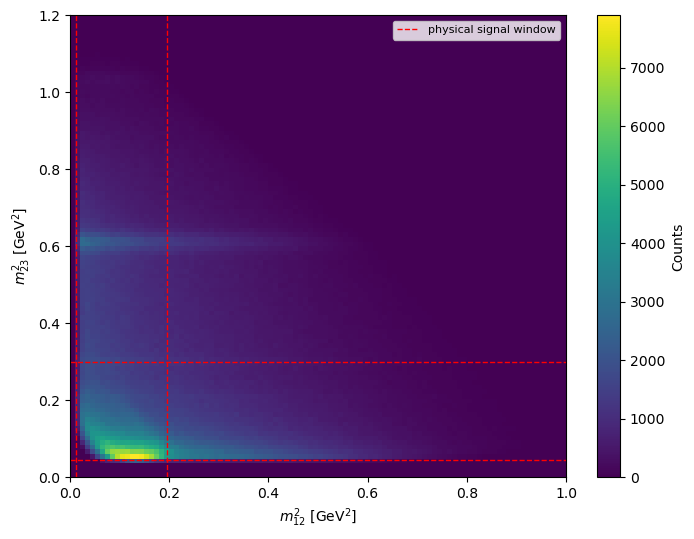

In [48]:
# Physical constraints for the dalitz plot
M_MU = 0.105658
M_ETA = 0.547862
M12_PHYS = (M_MU**2, (M_ETA - M_MU)**2)
M23_PHYS = ((2 * M_MU)**2, M_ETA**2)

# Test implementation with a quick plot of the Dalitz distribution
plt.figure(figsize=(8, 6))
plt.hist2d(m12s, m23s, bins=100, cmap='viridis', range=[[0, 1.0], [0, 1.2]])
plt.colorbar(label='Counts')

# Mark the physical signal boundary (see M12_PHYS/M23_PHYS above).
plt.axvline(M12_PHYS[0], color="red", ls="--", lw=1, label="physical signal window")
plt.axvline(M12_PHYS[1], color="red", ls="--", lw=1)
plt.axhline(M23_PHYS[0], color="red", ls="--", lw=1)
plt.axhline(M23_PHYS[1], color="red", ls="--", lw=1)

plt.legend(loc="upper right", fontsize=8)
plt.xlabel(r'$m_{12}^2$ [GeV$^2$]')
plt.ylabel(r'$m_{23}^2$ [GeV$^2$]')

Text(0, 0.5, '$m_{23}^2$ [GeV$^2$]')

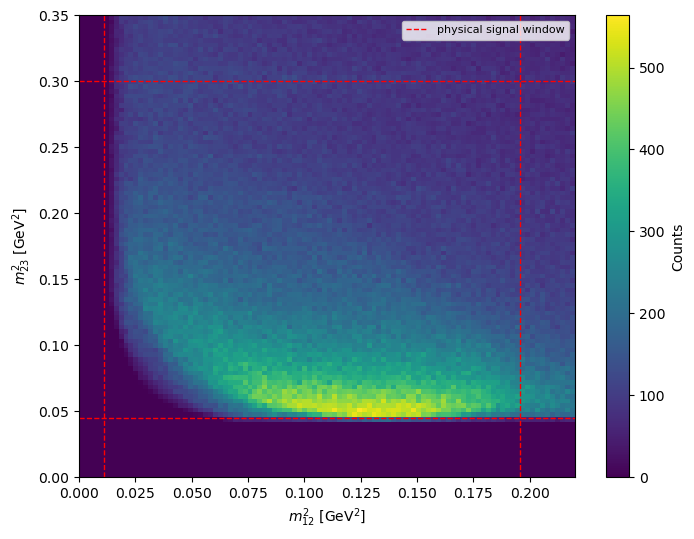

In [46]:
# Test implementation with a quick plot of the Dalitz distribution in physical range
plt.figure(figsize=(8, 6))
plt.hist2d(m12s, m23s, bins=100, cmap='viridis', range=[[0, 0.22], [0, 0.35]])
plt.colorbar(label='Counts')

# Mark the physical signal boundary (see M12_PHYS/M23_PHYS above).
plt.axvline(M12_PHYS[0], color="red", ls="--", lw=1, label="physical signal window")
plt.axvline(M12_PHYS[1], color="red", ls="--", lw=1)
plt.axhline(M23_PHYS[0], color="red", ls="--", lw=1)
plt.axhline(M23_PHYS[1], color="red", ls="--", lw=1)

plt.legend(loc="upper right", fontsize=8)
plt.xlabel(r'$m_{12}^2$ [GeV$^2$]')
plt.ylabel(r'$m_{23}^2$ [GeV$^2$]')

In [33]:
# Perform fit on the mass distribution
result = fit_gauss(infile=infile, xmin=400.0, xmax=696.0, nbins=80,
                   mean_init=547.9, sigma_init=10.0)

shape: (81,)
min/max: 0.0 1.0
monotonic: True
shape: (81,)
min/max: 0.0 1.0
monotonic: True


[info] 920316 entries in [400.0, 696.0] MeV across 80 bins
[fit] valid=True  mean=548.344±0.065 MeV  σ=15.076±0.074 MeV
[fit] χ²/ndf = 11.9791  (886.45 / 74)


[DONE] Plot saved to ../../out/eta2mumugamma/turbo/20260608/global_gauss_fit.png.

────────────────────────────────────────────────
                Fit summary                 
────────────────────────────────────────────────
μ = 548.34 ± 0.06 MeV
σ = 15.08 ± 0.07 MeV
χ²/ndof = 11.98
────────────────────────────────────────────────


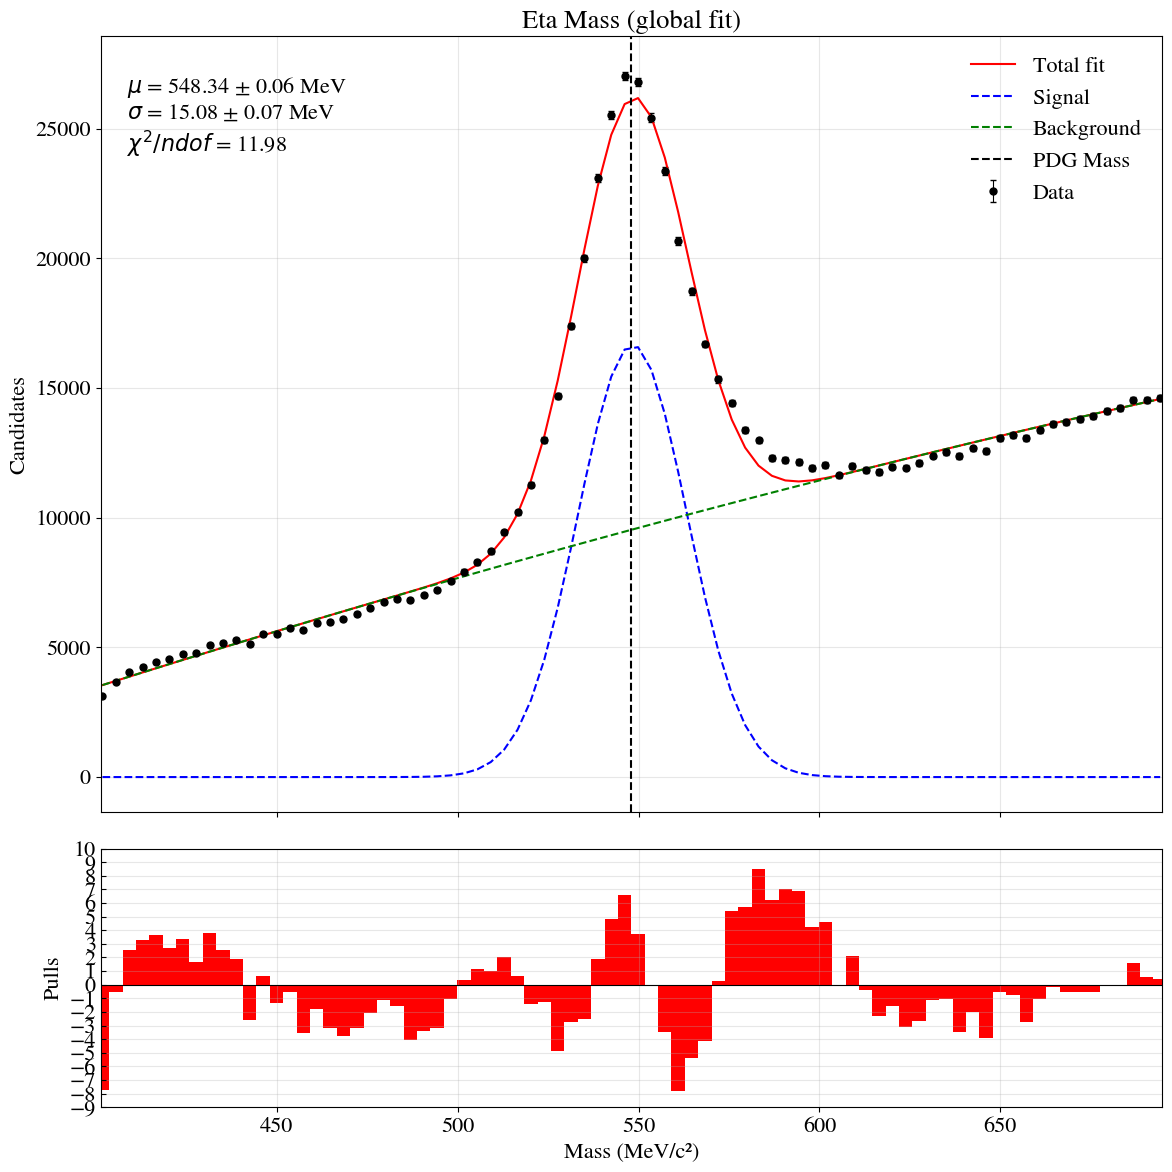

In [34]:
# Plot results of the fit
# plot_fit_data (not plot_fit) since we already have `result` in memory --
# plot_fit is a CLI-only wrapper that parses sys.argv and loads its own JSON
# from disk, which doesn't apply here.
plot_config = {
    "output": os.path.join(outdir, "global_gauss_fit.png"),
    "title": "Eta Mass (global fit)",
    "build_text": build_text,
}
plot_fit_data(result, plot_config)

In [35]:
# Now repeat for per-bin fitting based on m12 and m23
# Define bins
# Loop over bins
# Perform fit in each bin
def fit_gauss_per_bin(masses, xmin=400.0, xmax=696.0, nbins=80,
                      mean_init=547.9, sigma_init=10.0, c0_init=0.0, c1_init=0.0):
    """Fit a Gaussian to the mass distribution in each bin of m12 and m23."""
    # Define bin edges for m12 and m23
    counts, edges = np.histogram(masses, bins=nbins, range=(xmin, xmax))
    counts = counts.astype(float)  # Ensure counts are float for fitting
    centers = 0.5 * (edges[:-1] + edges[1:])
    errors = np.sqrt(counts)  # Poisson errors
    N = counts.sum()

    # Fit Gaussian to histogram
    cost = fit_utils.make_gauss_cost(counts, edges, xmin, xmax)

    # Use global fit parameters as initial values for per-bin fits
    init = dict(
        mean=mean_init,
        sigma=sigma_init,
        n_sig = N * 0.5,
        n_bkg = N * 0.5,
        c0=c0_init,
        c1=c1_init
    )
    limits = dict(
        mean  = (xmin, xmax),
        sigma = (1.0, 50.0),
        n_sig = (0.0, N * 2),
        n_bkg = (0.0, N * 2),
        c0    = (-1.0, 1.0),
        c1    = (-1.4, 1.4),
    )

    # m == fit result object containing fit parameters, errors, and goodness-of-fit metrics
    m = fit_utils.run_fit(cost, init, limits, fixed=["mean", "sigma", "c0", "c1"])
    return m


In [39]:
def fig_gauss_binned(m12s, m23s, masses, xmin=400.0, xmax=696.0, nbins=80,
                      mean_init=547.9, sigma_init=10.0, c0_init=0.0, c1_init=0.0):
    """Run per-bin Gaussian fit for each bin of m12 and m23. Return a dictionary
    of the fit results.
    """
    # Define bin edges for m12 and m23
    # Get max and min values for m12 and m23 to define the bin edges
    # m12_min, m12_max = m12s.min(), m12s.max()
    # m23_min, m23_max = m23s.min(), m23s.max()
    # Or choose a fixed range for m12 and m23 based on physical considerations
    m12_min, m12_max = 0.0, 0.21
    m23_min, m23_max = 0.0, 0.31
    # nbins is the total number of bins for the 2D histogram, so we need to take
    # the square root to get the number of bins in each dimension and round to
    # the nearest integer.
    nbins_per_dim = int(np.sqrt(nbins))
    # Now use nbins to define the bin edges for m12 and m23
    m12_edges = np.linspace(m12_min, m12_max, nbins_per_dim + 1)
    m23_edges = np.linspace(m23_min, m23_max, nbins_per_dim + 1)
    # Create a 2D histogram of m12 and m23
    hist2d, m12_edges, m23_edges = np.histogram2d(m12s, m23s, bins=[m12_edges, m23_edges])
    # Prepare a dictionary to hold the fit results for each bin
    fit_results = {}
    # Loop over each bin in the 2D histogram
    for i in range(nbins_per_dim):
        for j in range(nbins_per_dim):
            # Get the bin edges for this bin
            m12_bin_min, m12_bin_max = m12_edges[i], m12_edges[i + 1]
            m23_bin_min, m23_bin_max = m23_edges[j], m23_edges[j + 1]
            # Select masses that fall within this bin
            mask = (
                (m12s >= m12_bin_min) & (m12s < m12_bin_max) &
                (m23s >= m23_bin_min) & (m23s < m23_bin_max)
            )
            masses_in_bin = masses[mask]
            # If there are enough events in the bin, perform the fit
            if len(masses_in_bin) > 10:  # Arbitrary threshold for fitting
                fit_result = fit_gauss_per_bin(masses_in_bin, xmin, xmax, nbins,
                                               mean_init, sigma_init, c0_init, c1_init)
                fit_results[(i, j)] = {
                    "fit": fit_result,
                    "n_events": len(masses_in_bin),
                    "m12_range": (m12_bin_min, m12_bin_max),
                    "m23_range": (m23_bin_min, m23_bin_max),
                }
    return fit_results, m12_edges, m23_edges

In [43]:
mean_init = result["fit"]["parameters"]["mean"]["value"]
sigma_init = result["fit"]["parameters"]["sigma"]["value"]
c0_init = result["fit"]["parameters"]["c0"]["value"]
c1_init = result["fit"]["parameters"]["c1"]["value"]
nbins=400
fit_results, m12_edges, m23_edges = fig_gauss_binned(m12s, m23s, masses, 
                                                     xmin=400.0, xmax=696.0, 
                                                     nbins=nbins, 
                                                     mean_init=mean_init, 
                                                     sigma_init=sigma_init, 
                                                     c0_init=c0_init, 
                                                     c1_init=c1_init)
# Extract the number of signal events from the fit results for each bin
signal_counts = np.zeros((int(np.sqrt(nbins)), int(np.sqrt(nbins))))
for (i, j), bin_result in fit_results.items():
    signal_counts[i, j] = bin_result["fit"].values["n_sig"] if bin_result["fit"].valid else 0
# Extract the number of background events from the fit results for each bin
bkg_counts = np.zeros((int(np.sqrt(nbins)), int(np.sqrt(nbins))))
for (i, j), bin_result in fit_results.items():
    bkg_counts[i, j] = bin_result["fit"].values["n_bkg"] if bin_result["fit"].valid else 0


/tmp/ipykernel_852557/1744436928.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


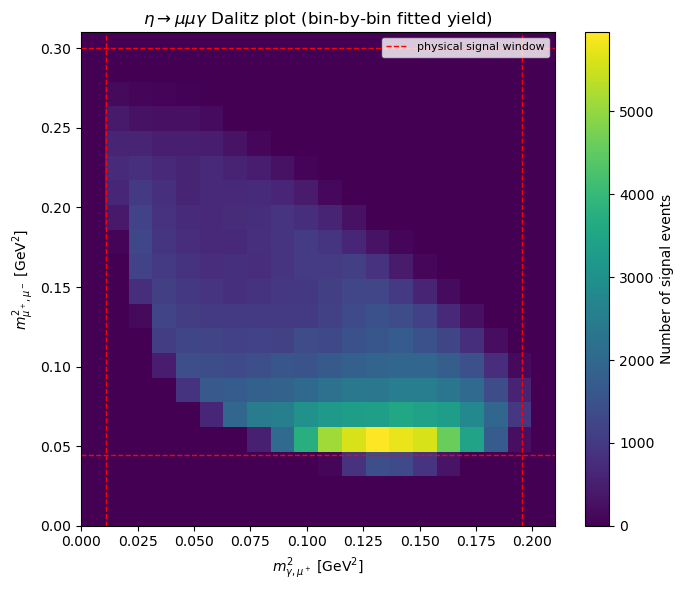

In [44]:
# Plot the dalitz plot using the fit results for signal events
# Physical constraints for the dalitz plot
M_MU = 0.105658
M_ETA = 0.547862
M12_PHYS = (M_MU**2, (M_ETA - M_MU)**2)
M23_PHYS = ((2 * M_MU)**2, M_ETA**2)

# Reset plot settings to defaults
plt.rcdefaults()

fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(m12_edges, m23_edges, signal_counts.T, cmap='viridis', shading='auto')
fig.colorbar(mesh, ax=ax, label='Number of signal events')

# Mark the physical signal boundary (see M12_PHYS/M23_PHYS above).
ax.axvline(M12_PHYS[0], color="red", ls="--", lw=1, label="physical signal window")
ax.axvline(M12_PHYS[1], color="red", ls="--", lw=1)
ax.axhline(M23_PHYS[0], color="red", ls="--", lw=1)
ax.axhline(M23_PHYS[1], color="red", ls="--", lw=1)
ax.legend(loc="upper right", fontsize=8)

ax.set_xlabel(r"$m^2_{\gamma,\mu^+}$ [GeV$^2$]")
ax.set_ylabel(r"$m^2_{\mu^+,\mu^-}$ [GeV$^2$]")
ax.set_title(r"$\eta \to \mu\mu\gamma$ Dalitz plot (bin-by-bin fitted yield)")

fig.tight_layout()
fig.show()

/tmp/ipykernel_852557/1643071413.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


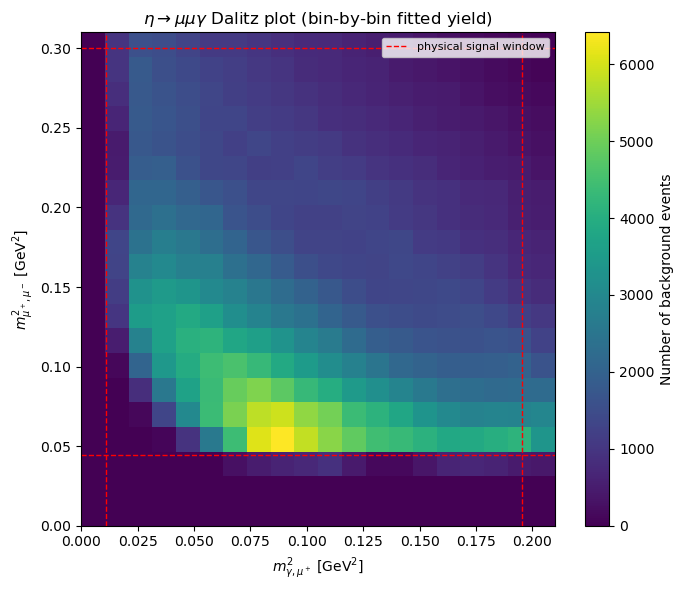

In [45]:
# Repeat for the background events
fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(m12_edges, m23_edges, bkg_counts.T, cmap='viridis', shading='auto')
fig.colorbar(mesh, ax=ax, label='Number of background events')

# Mark the physical signal boundary (see M12_PHYS/M23_PHYS above).
ax.axvline(M12_PHYS[0], color="red", ls="--", lw=1, label="physical signal window")
ax.axvline(M12_PHYS[1], color="red", ls="--", lw=1)
ax.axhline(M23_PHYS[0], color="red", ls="--", lw=1)
ax.axhline(M23_PHYS[1], color="red", ls="--", lw=1)
ax.legend(loc="upper right", fontsize=8)

ax.set_xlabel(r"$m^2_{\gamma,\mu^+}$ [GeV$^2$]")
ax.set_ylabel(r"$m^2_{\mu^+,\mu^-}$ [GeV$^2$]")
ax.set_title(r"$\eta \to \mu\mu\gamma$ Dalitz plot (bin-by-bin fitted yield)")

fig.tight_layout()
fig.show()